In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [ ]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [ ]:
raw_datasets

In [ ]:
raw_datasets['train']

In [ ]:
from datasets import DatasetDict

In [ ]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [ ]:
raw_datasets

In [ ]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

In [ ]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

In [ ]:
raw_train_dataset[5]['label']

In [ ]:
raw_train_dataset[5]['idx']

In [ ]:
raw_train_dataset.features

# 2. Preprocess

In [ ]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

# 3. Preparing for Training

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [ ]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

# 4. Loading model

In [ ]:
import sys
sys.path.insert(0, '../')

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [ ]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

In [ ]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [ ]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

In [ ]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

### Load Trained Weights

In [ ]:
load_path = './glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

In [ ]:
from train_eval_func import eval_loop

In [ ]:
eval_loop(model, val_dataloader, task_name, device)[0]

# 5. Importance Score Eval

In [ ]:
from structure_prune_helper import compute_importance_scores

In [ ]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [ ]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

In [ ]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

In [ ]:
head_importance

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
head_scores = torch.stack(head_importance).cpu()

# Sum all heads inside each layer
layer_scores = head_scores.sum(dim=1)

print(layer_scores.shape)  # [6]
print(layer_scores)

In [ ]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

In [ ]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

### Top-K Head Scores

In [45]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([12])
tensor([4.9013e-06, 5.1856e-06, 5.0391e-06, 5.3778e-06, 3.6342e-06, 4.9172e-06,
        1.9076e-06, 1.4378e-06, 1.8605e-06, 1.7427e-06, 6.7319e-07, 5.1360e-07])


In [46]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.9020, 0.9605, 0.9304, 1.0000, 0.6415, 0.9053, 0.2866, 0.1900, 0.2769,
        0.2527, 0.0328, 0.0000])

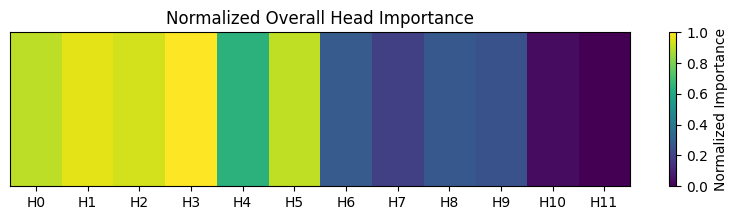

In [47]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [39]:
neuron_scores = torch.stack(neuron_importance).cpu()

# Sum all heads inside each layer
layer_scores = neuron_scores.sum(dim=1)

print(layer_scores.shape)  # [6]
print(layer_scores)

torch.Size([12])
tensor([3.9683e-04, 3.9753e-04, 4.6750e-04, 4.6105e-04, 4.5300e-04, 3.1138e-04,
        2.9413e-04, 2.6706e-04, 1.8576e-04, 9.7265e-05, 5.9676e-05, 3.5843e-05])


In [40]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.8363, 0.8379, 1.0000, 0.9851, 0.9664, 0.6383, 0.5984, 0.5356, 0.3473,
        0.1423, 0.0552, 0.0000])

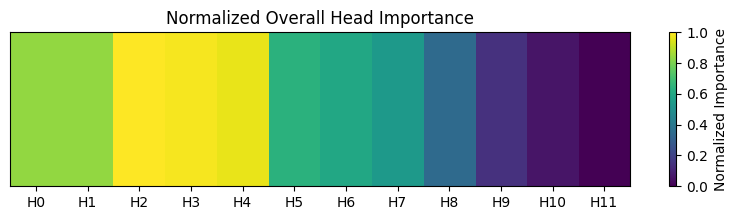

In [41]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [40]:
import torch.nn as nn

In [41]:
model.bert.encoder.layer = nn.ModuleList(
    [layer for i, layer in enumerate(model.bert.encoder.layer) if i != 4]
)
model.config.num_hidden_layers = len(model.bert.encoder.layer)

In [42]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8455882352941176, 'f1': 0.8856624319419237}

In [78]:
int(torch.min(normalized_scores))

0

In [79]:
normalized_scores

tensor([0.9020, 0.9605, 0.9304, 1.0000, 0.6415, 0.9053, 0.2866, 0.1900, 0.2769,
        0.2527, 0.0328, 0.0000])

In [80]:
torch.argmin(normalized_scores)

tensor(0.)